<a href="https://colab.research.google.com/github/santhosh-kumar1928/santhoshkumar-codeboosters-2026/blob/main/day2/day2_miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# import the libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All librariries imported")
print(f"pandas version {pd.__version__}")
print(f"sqlite3 version {sqlite3.version}")

All librariries imported
pandas version 2.2.2
sqlite3 version 2.6.0


In [3]:
# load the dataset
df = pd.read_csv('student_performance.csv')
print(f"Dataset loaded:{df.shape[0]} students, {df.shape[1]} columns")
conn = sqlite3.connect('college.db')
cursor = conn.cursor()

Dataset loaded:30 students, 13 columns


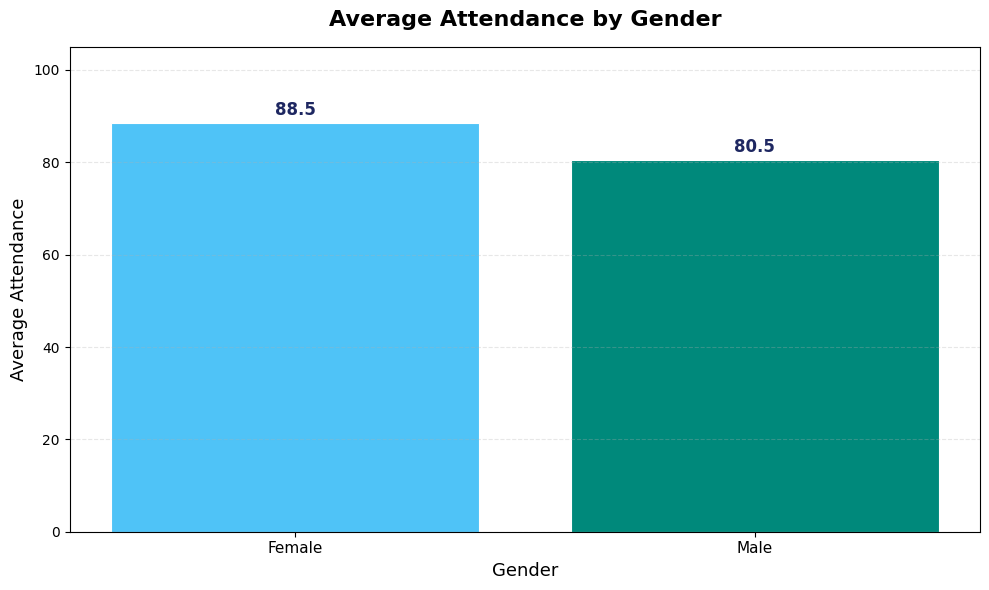

In [4]:
conn = sqlite3.connect('students.db')

# Create the 'students' table from the DataFrame 'df'
# This will overwrite the table if it already exists
df.to_sql('students', conn, if_exists='replace', index=False)

#Get data using SQL
chart1_sql = """
SELECT gender, ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY gender
ORDER BY avg_attendance DESC
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


#Create thr bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_color = ['#4FC3F7','#00897B','#E67E22','#8E44AD']

bars = ax.bar(chart1_data['gender'], chart1_data['avg_attendance'], color=bar_color, edgecolor = 'white', linewidth = 0.8)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight = 'bold',
        color='#1E2761'
    )

ax.set_title('Average Attendance by Gender', fontsize=16, fontweight='bold', pad = 15)
ax.set_xlabel('Gender', fontsize = 13)
ax.set_ylabel('Average Attendance', fontsize = 13)
ax.set_ylim(0,105) # Assuming attendance is a percentage or score out of 100
ax.tick_params(axis='x', labelsize = 11)
ax.grid(axis='y', alpha = 0.3, linestyle ='--')

plt.tight_layout()
plt.show()

conn.close() # Close the connection

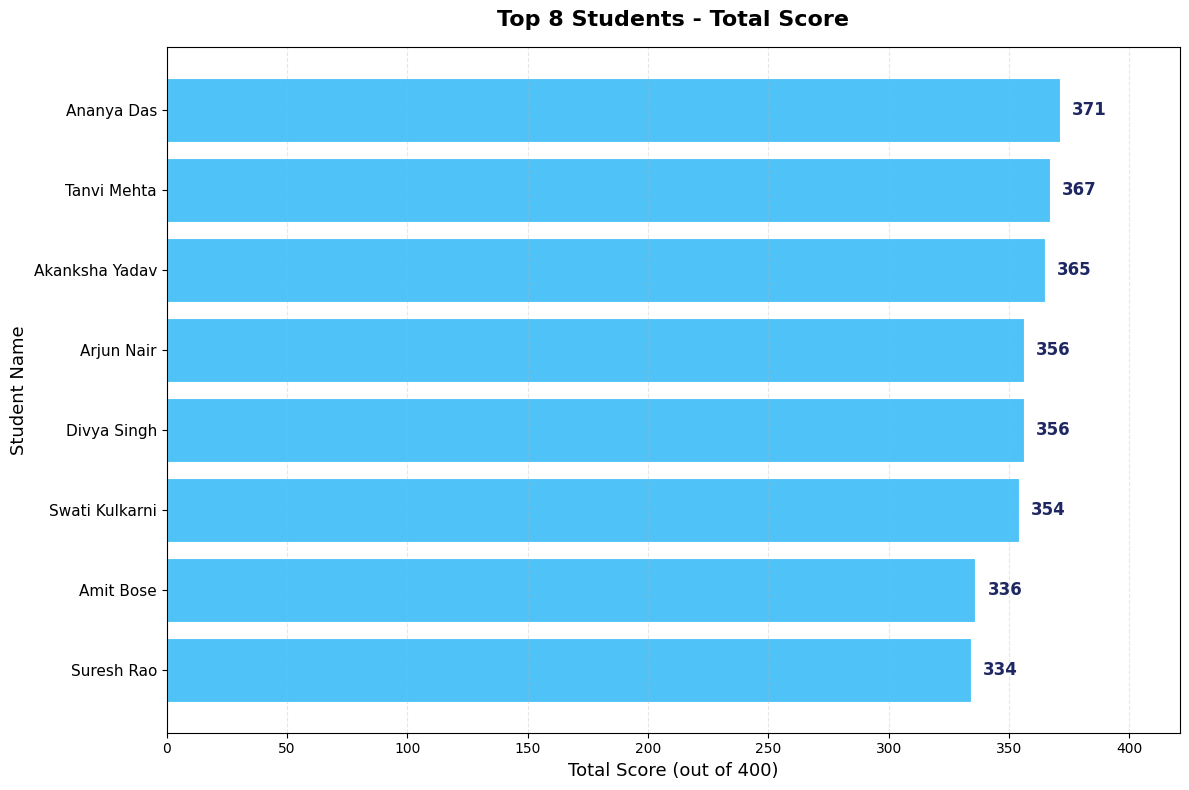

In [5]:
conn = sqlite3.connect('students.db')

# Get data using SQL for top 8 students by total score
chart1_sql = """
SELECT name, (math_score + science_score + english_score +programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 8
"""

chart1_data = pd.read_sql_query(chart1_sql, conn)


# Create the bar chart
fig, ax = plt.subplots(figsize=(12, 8))

bar_color = ['#4FC3F7']

bars = ax.barh(chart1_data['name'], chart1_data['total_score'], color=bar_color, edgecolor = 'white', linewidth = 0.8)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 5, # Adjust position for text
        bar.get_y() + bar.get_height() / 2,
        f'{width:.0f}', # Display as integer
        ha='left',
        va='center',
        fontsize=12,
        fontweight = 'bold',
        color='#1E2761'
    )

ax.set_title('Top 8 Students - Total Score', fontsize=16, fontweight='bold', pad = 15)
ax.set_ylabel('Student Name', fontsize = 13)
ax.set_xlabel('Total Score (out of 400)', fontsize = 13)
ax.set_xlim(0, chart1_data['total_score'].max() + 50) # Adjust x-limit dynamically
ax.tick_params(axis='y', labelsize = 11)
ax.grid(axis='x', alpha = 0.3, linestyle ='--')

plt.gca().invert_yaxis() # Invert y-axis to have the highest score at the top
plt.tight_layout()
plt.show()

conn.close() # Close the connection

